# Beyond Glicko-2: Hierarchical Bayesian Estimation of Latent Chess Skill**Bayesian ML Final Project**Lichess rates players with Glicko-2 — itself an *approximate* sequential Bayesianfilter: it holds a Gaussian belief over each player's skill, but with a hand-setvolatility constant, opponents treated as fixed and known, and no informationshared across players or time controls. This project writes down the fullgenerative model Glicko-2 approximates and computes its posterior properly:a hierarchical dynamic state-space model of skill, fit with a hand-writtenblocked Gibbs sampler (Albert–Chib data augmentation + forward-filteringbackward-sampling).**Task:** Estimate each player's unobserved, time-varying skill from gameoutcomes alone, with honest uncertainty — then measure where Glicko-2'sapproximations cost it accuracy using two lenses1. *Information-fair* — same data as Glicko-2, better inference. Scored   prospectively (filtered predictions, terminal holdout) so the comparison   isn't rigged.2. *Value of information* — channels Glicko-2 ignores (termination type, game   length, clock usage), measured as bits-per-game.**Data:** 21,603 highly active blitz players over 12 months (2025-06 → 2026-05)from the Lichess Open Database; ~5.5M games in one connected comparison graph,with a 2-month terminal holdout.**Baseline to beat (holdout RPS):** Glicko-2, fully tuned: **0.47988**.

# What Glicko-2 actually doesIt maintains, for each player, a Gaussian belief about their skill — a mean (the rating) and a spread (the rating deviation). After each game it nudges those numbers. That's approximate Bayesian filtering. But it makes four sacrifices for speed:Sequential, not joint. It updates one player at a time, treating opponents' ratings as fixed known constants. They aren't — they're uncertain quantities being estimated from the same games.Hand-set drift. How fast skill is allowed to change is a constant Glickman chose by hand (the volatility τ), not learned from data.No information sharing. Four separate rating systems for bullet/blitz/rapid/classical, zero transfer between them.Gaussian-everything, one game at a time. No draw model, no notion of a player improving on a trend.# What we're building insteadA hierarchical dynamic Bayesian state-space model, in layers:- The likelihood — how a game outcome is produced. You never observe skill. You posit a hidden performance-difference for each game:D = θ(white) − θ(black) + h + noiseand the observed win/draw/loss is just which region D lands in (h is the white-move advantage; the draw band has half-width γ). This is the ordered probit. It's what lets a discrete outcome speak about a continuous skill difference.- The dynamics — skill drifts over time. Each player's skill is a random walk across your 12 monthly buckets:θ(t) = θ(t−1) + noise, with variance τ- The hierarchy — players and formats aren't independent. Skills are drawn from a shared population distribution (so a 15-game player shrinks sensibly toward the population instead of being noise), and each player's format-specific skills share a covariance Σ — which lets you measure how much blitz skill predicts bullet skill, the thing Glicko-2 throws away by running four separate systems.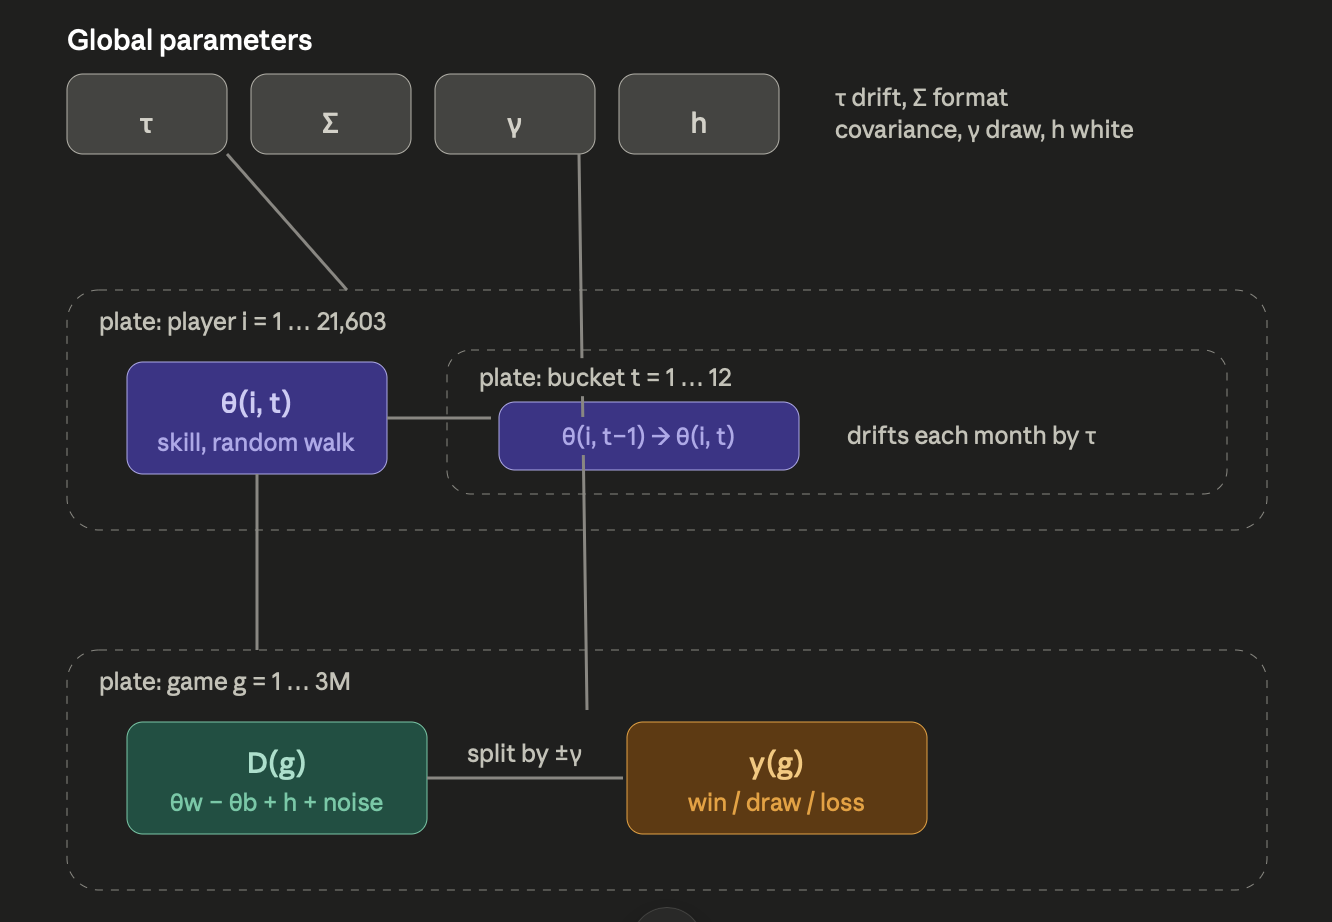**Top:** the global parameters (τ, Σ, γ, h) — the shared knobs. τ controls how fast skill drifts, Σ the format covariance, γ the draw margin, h the white advantage. These are what Glicko-2 either fixes by hand (τ) or lacks entirely (Σ, γ). One set, shared across everyone.**Middle:** players. Each of the 21,603 players has a skill θ(i,t) that isn't one number — it's a trajectory across the 12 monthly buckets, drifting by τ each step (the inner plate). This is the layer your static model collapses to a single value; FFBS is what turns it into the trajectory shown here.**Bottom:** games. Each of the ~3M games pulls the two players' current skills, forms the hidden performance-difference D(g) = θw − θb + h + noise, and the observed outcome y(g) is just which side of ±γ that D lands on.The inference runs the arrows backwards. You observe only y(g) at the bottom, and the sampler works upward to recover the θ trajectories and the global parameters — the posterior. The three Gibbs steps map onto the three levels: augment recovers D(g) from y(g), FFBS recovers the θ plate, and the hyperparameter draws recover the top row.

## SetupAll imports and configuration. `jax_enable_x64` must run before any JAX arrayis created — float32 silently degrades posterior coverage at this scale.

In [1]:
# --- imports --------------------------------------
import os, json, time
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import duckdb
import requests
from collections import deque

import jax
jax.config.update("jax_enable_x64", True)          # BEFORE any jax array
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import ndtr, ndtri

from google.colab import drive
drive.mount('/content/drive')

ROOT = '/content/drive/MyDrive/Colab Notebooks/Bayes ML Final Project/data'
print('setup complete')

Mounted at /content/drive
setup complete


## Shared helpers`rps` (Ranked Probability Score) is the scoring rule for ordered outcomes —defined once here and reused everywhere.

In [2]:
def rps(p, yy):
    """Ranked Probability Score for ordered outcomes (0<1<2)."""
    cp = np.cumsum(p, axis=1)[:, :-1]
    oh = np.cumsum(np.eye(3)[yy], axis=1)[:, :-1]
    return ((cp - oh) ** 2).sum(1).mean()

## SamplersBoth samplers share `_sample_D` (truncated-normal augmentation) and `_loglik`(ordered-probit likelihood), defined once. `gibbs_static_jax` fits one skillper player; `gibbs_dynamic_jax` fits a per-bucket trajectory via FFBS with aGlicko-seeded bucket-0 prior.

In [3]:
# --- shared sampler primitives ---------------------------------------
def _sample_D(key, mu, y, gamma):
    """Truncated-normal augmentation via inverse-CDF, GPU-native.
    y: 0 black win, 1 draw, 2 white win. mu already includes h."""
    lo = jnp.where(y == 2, gamma, jnp.where(y == 1, -gamma, -jnp.inf))
    hi = jnp.where(y == 2, jnp.inf, jnp.where(y == 1, gamma, -gamma))
    Fa = ndtr(lo - mu)
    Fb = ndtr(hi - mu)
    u = random.uniform(key, mu.shape, dtype=mu.dtype)
    p = jnp.clip(Fa + u * (Fb - Fa), 1e-12, 1 - 1e-12)
    return mu + ndtri(p)


def _loglik(mu_no_h, y, gamma, h):
    """Ordered-probit total log-likelihood. mu_no_h = theta_w - theta_b."""
    z = mu_no_h + h
    pW = ndtr(z - gamma)
    pL = ndtr(-gamma - z)
    pD = jnp.clip(1.0 - pW - pL, 1e-12, 1.0)
    p = jnp.where(y == 2, pW, jnp.where(y == 0, pL, pD))
    return jnp.sum(jnp.log(jnp.clip(p, 1e-12, 1.0)))

In [4]:
# --- STATIC sampler (one theta per player) ---------------------------
def _make_sweep_static(w, b, y, n_players, sigma_theta, step_g, step_h):
    w = jnp.asarray(w); b = jnp.asarray(b); y = jnp.asarray(y)
    prior_prec = 1.0 / sigma_theta**2
    counts = (jnp.bincount(w, length=n_players)
              + jnp.bincount(b, length=n_players)).astype(jnp.float64)
    post_prec = prior_prec + counts
    post_sd = jnp.sqrt(1.0 / post_prec)

    @jax.jit
    def sweep(state, key):
        theta, gamma, h, acc_g, acc_h = state
        k_D, k_th, k_h, k_g, k_uh, k_ug = random.split(key, 6)
        mu = theta[w] - theta[b]

        D = _sample_D(k_D, mu + h, y, gamma)

        resid = D - h
        obs_w = resid + theta[b]
        obs_b = -resid + theta[w]
        sum_obs = (jnp.bincount(w, weights=obs_w, length=n_players)
                   + jnp.bincount(b, weights=obs_b, length=n_players))
        post_mean = sum_obs / post_prec
        theta = post_mean + post_sd * random.normal(k_th, (n_players,), jnp.float64)
        theta = theta - jnp.mean(theta)              # sum-to-zero anchor
        mu = theta[w] - theta[b]

        h_prop = h + step_h * random.normal(k_h, (), jnp.float64)
        d_h = _loglik(mu, y, gamma, h_prop) - _loglik(mu, y, gamma, h)
        acc = jnp.log(random.uniform(k_uh, (), jnp.float64)) < d_h
        h = jnp.where(acc, h_prop, h); acc_h = acc_h + acc.astype(jnp.float64)

        g_prop = gamma + step_g * random.normal(k_g, (), jnp.float64)
        d_g = _loglik(mu, y, g_prop, h) - _loglik(mu, y, gamma, h)
        acc = (g_prop > 0) & (jnp.log(random.uniform(k_ug, (), jnp.float64)) < d_g)
        gamma = jnp.where(acc, g_prop, gamma); acc_g = acc_g + acc.astype(jnp.float64)

        return (theta, gamma, h, acc_g, acc_h)
    return sweep


def gibbs_static_jax(w, b, y, n_players,
                     n_sweeps=2000, burn=500, thin=2,
                     sigma_theta=3.0, step_g=0.002, step_h=0.005,
                     seed=0, report_every=250):
    sweep = _make_sweep_static(w, b, y, n_players, sigma_theta, step_g, step_h)
    key = random.PRNGKey(seed)
    state = (jnp.zeros(n_players, jnp.float64),
             jnp.asarray(0.2), jnp.asarray(0.05),
             jnp.asarray(0.0), jnp.asarray(0.0))
    keep_theta, keep_gamma, keep_h = [], [], []
    t0 = time.time()
    for s in range(n_sweeps):
        key, sk = random.split(key)
        state = sweep(state, sk)
        if s >= burn and (s - burn) % thin == 0:
            keep_theta.append(np.asarray(state[0]))
            keep_gamma.append(float(state[1])); keep_h.append(float(state[2]))
        if s % report_every == 0:
            _, gm, hh, ag, ah = state
            print(f'  sweep {s:4d}  gamma {float(gm):.4f}  h {float(hh):.4f}  '
                  f'acc_h {float(ah)/(s+1):.2f}  acc_g {float(ag)/(s+1):.2f}  '
                  f'[{time.time()-t0:.0f}s]')
    return {'theta': np.array(keep_theta), 'gamma': np.array(keep_gamma),
            'h': np.array(keep_h),
            'acc_h': float(state[4])/n_sweeps, 'acc_g': float(state[3])/n_sweeps}

In [5]:
# --- DYNAMIC sampler (FFBS trajectory, Glicko-seeded prior) -----------
def _ffbs_all(key, obs_sum, obs_prec, tau2, sigma0_2, prior_mean0):
    """Forward-filter backward-sample every player's trajectory at once.
    prior_mean0[i] : bucket-0 prior mean for player i (Glicko-seeded)."""
    n_p, n_t = obs_sum.shape

    def one_player(k, o_sum, o_prec, m0):
        def fwd(carry, t):
            m_prev, P_prev = carry
            P_pred = P_prev + tau2
            prec = 1.0 / P_pred + o_prec[t]
            mean = (m_prev / P_pred + o_sum[t]) / prec
            var = 1.0 / prec
            return (mean, var), (mean, var)
        (mT, PT), (mf, Pf) = lax.scan(fwd, (m0, sigma0_2), jnp.arange(n_t))

        ks = random.split(k, n_t)
        thT = mf[-1] + jnp.sqrt(Pf[-1]) * random.normal(ks[-1], (), jnp.float64)
        def bwd(th_next, t):
            J = Pf[t] / (Pf[t] + tau2)
            m = mf[t] + J * (th_next - mf[t])
            v = Pf[t] * (1.0 - J)
            th = m + jnp.sqrt(jnp.clip(v, 1e-30, None)) * random.normal(ks[t], (), jnp.float64)
            return th, th
        _, th_rev = lax.scan(bwd, thT, jnp.arange(n_t - 1)[::-1])
        return jnp.concatenate([th_rev[::-1], thT[None]])

    keys = random.split(key, n_p)
    return jax.vmap(one_player)(keys, obs_sum, obs_prec, prior_mean0)


def _make_sweep_dyn(w, b, y, t_idx, n_players, n_buckets,
                    step_g, step_h, sigma0_2, a_tau, b_tau, prior_mean0):
    w = jnp.asarray(w); b = jnp.asarray(b); y = jnp.asarray(y)
    t_idx = jnp.asarray(t_idx)
    prior_mean0 = jnp.asarray(prior_mean0)
    flat  = w * n_buckets + t_idx
    flatb = b * n_buckets + t_idx
    n_pt = n_players * n_buckets

    @jax.jit
    def sweep(state, key):
        theta, gamma, h, tau2, acc_g, acc_h = state
        kD, kth, kh, kg, kuh, kug, ktau = random.split(key, 7)
        th_w = theta[w, t_idx]; th_b = theta[b, t_idx]
        mu = th_w - th_b

        D = _sample_D(kD, mu + h, y, gamma)
        resid = D - h
        obs_w = resid + th_b
        obs_b = -resid + th_w
        sum_flat = jnp.zeros(n_pt, jnp.float64).at[flat].add(obs_w).at[flatb].add(obs_b)
        cnt_flat = jnp.zeros(n_pt, jnp.float64).at[flat].add(1.0).at[flatb].add(1.0)
        obs_sum = sum_flat.reshape(n_players, n_buckets)
        obs_prec = cnt_flat.reshape(n_players, n_buckets)

        theta = _ffbs_all(kth, obs_sum, obs_prec, tau2, sigma0_2, prior_mean0)
        # no sum-to-zero anchor: the Glicko-seeded prior fixes each level
        th_w = theta[w, t_idx]; th_b = theta[b, t_idx]
        mu = th_w - th_b

        hp = h + step_h * random.normal(kh, (), jnp.float64)
        d_h = _loglik(mu, y, gamma, hp) - _loglik(mu, y, gamma, h)
        acc = jnp.log(random.uniform(kuh, (), jnp.float64)) < d_h
        h = jnp.where(acc, hp, h); acc_h = acc_h + acc.astype(jnp.float64)

        gp = gamma + step_g * random.normal(kg, (), jnp.float64)
        d_g = _loglik(mu, y, gp, h) - _loglik(mu, y, gamma, h)
        acc = (gp > 0) & (jnp.log(random.uniform(kug, (), jnp.float64)) < d_g)
        gamma = jnp.where(acc, gp, gamma); acc_g = acc_g + acc.astype(jnp.float64)

        dth = theta[:, 1:] - theta[:, :-1]
        a_post = a_tau + 0.5 * n_players * (n_buckets - 1)
        b_post = b_tau + 0.5 * jnp.sum(dth ** 2)
        tau2 = b_post / random.gamma(ktau, a_post, (), jnp.float64)
        return (theta, gamma, h, tau2, acc_g, acc_h)
    return sweep


def gibbs_dynamic_jax(w, b, y, t_idx, n_players, n_buckets, glicko_theta0,
                      n_sweeps=2000, burn=500, thin=2,
                      step_g=0.002, step_h=0.005, sigma0=1.0,
                      a_tau=2.0, b_tau=0.001, seed=0, report_every=250):
    sweep = _make_sweep_dyn(w, b, y, t_idx, n_players, n_buckets,
                            step_g, step_h, sigma0**2, a_tau, b_tau, glicko_theta0)
    key = random.PRNGKey(seed)
    theta0 = jnp.tile(jnp.asarray(glicko_theta0)[:, None], (1, n_buckets))
    state = (theta0, jnp.asarray(0.06), jnp.asarray(0.05), jnp.asarray(0.05),
             jnp.asarray(0.0), jnp.asarray(0.0))
    keep_theta, keep_gamma, keep_h, keep_tau = [], [], [], []
    t0 = time.time()
    for s in range(n_sweeps):
        key, sk = random.split(key)
        state = sweep(state, sk)
        if s >= burn and (s - burn) % thin == 0:
            keep_theta.append(np.asarray(state[0]))
            keep_gamma.append(float(state[1])); keep_h.append(float(state[2]))
            keep_tau.append(float(jnp.sqrt(state[3])))
        if s % report_every == 0:
            _, gm, hh, t2, ag, ah = state
            print(f'  sweep {s:4d}  gamma {float(gm):.4f}  h {float(hh):.4f}  '
                  f'tau {float(jnp.sqrt(t2)):.4f}  acc_h {float(ah)/(s+1):.2f}  '
                  f'acc_g {float(ag)/(s+1):.2f}  [{time.time()-t0:.0f}s]')
    return {'theta': np.array(keep_theta), 'gamma': np.array(keep_gamma),
            'h': np.array(keep_h), 'tau': np.array(keep_tau),
            'acc_h': float(state[4])/n_sweeps, 'acc_g': float(state[3])/n_sweeps}

## Recovery checks (synthetic)Run before touching real data. A sampler that recovers known parameters withcorrect coverage is trustworthy; one that runs clean but gets coverage wronglies silently. The static check confirms the augmentation + conjugate update;the dynamic check confirms FFBS tracks drift, recovers tau, and is calibrated.

In [6]:
# --- STATIC recovery check -------------------------------------------
def make_synthetic(n_players=300, n_games=40000, gamma=0.15, h=0.05, seed=1):
    rng = np.random.default_rng(seed)
    theta_true = rng.normal(0, 1.0, n_players); theta_true -= theta_true.mean()
    w = rng.integers(0, n_players, n_games); b = rng.integers(0, n_players, n_games)
    keep = w != b; w, b = w[keep], b[keep]
    mu = theta_true[w] - theta_true[b] + h
    D = mu + rng.normal(0, 1, len(w))
    y = np.where(D > gamma, 2, np.where(D < -gamma, 0, 1)).astype(np.int8)
    return theta_true, w, b, y, gamma, h

theta_true, sw, sb, sy, g_true, h_true = make_synthetic()
print('static recovery check...')
_post = gibbs_static_jax(sw, sb, sy, len(theta_true),
                         n_sweeps=1500, burn=500, thin=2,
                         sigma_theta=1.0, step_g=0.01, step_h=0.02, seed=0)
theta_hat, theta_sd = _post['theta'].mean(0), _post['theta'].std(0)
z = (theta_hat - theta_true) / theta_sd
print(f'  corr {np.corrcoef(theta_true, theta_hat)[0,1]:.4f}  (want >0.95)')
print(f'  coverage {np.mean(np.abs(z)<1.96):.3f}  (want ~0.95)')
print(f'  gamma {_post["gamma"].mean():.3f} (true {g_true})  '
      f'h {_post["h"].mean():.3f} (true {h_true})')

static recovery check...
  sweep    0  gamma 0.1935  h 0.0500  acc_h 0.00  acc_g 1.00  [6s]
  sweep  250  gamma 0.1464  h 0.0536  acc_h 0.33  acc_g 0.31  [10s]
  sweep  500  gamma 0.1479  h 0.0490  acc_h 0.36  acc_g 0.30  [10s]
  sweep  750  gamma 0.1473  h 0.0594  acc_h 0.38  acc_g 0.31  [11s]
  sweep 1000  gamma 0.1474  h 0.0647  acc_h 0.39  acc_g 0.31  [11s]
  sweep 1250  gamma 0.1469  h 0.0464  acc_h 0.38  acc_g 0.31  [11s]
  corr 0.9950  (want >0.95)
  coverage 0.963  (want ~0.95)
  gamma 0.147 (true 0.15)  h 0.059 (true 0.05)


In [7]:
# --- DYNAMIC recovery check ------------------------------------------
def make_synthetic_dyn(n_players=300, n_buckets=12, games_per=4000,
                       tau_true=0.15, gamma=0.06, h=0.045, seed=1):
    rng = np.random.default_rng(seed)
    steps = rng.normal(0, tau_true, (n_players, n_buckets))
    steps[:, 0] = rng.normal(0, 1.0, n_players)
    theta = np.cumsum(steps, axis=1); theta -= theta[:, 0].mean()
    w = rng.integers(0, n_players, games_per * n_buckets)
    b = rng.integers(0, n_players, games_per * n_buckets)
    t = rng.integers(0, n_buckets, games_per * n_buckets)
    keep = w != b; w, b, t = w[keep], b[keep], t[keep]
    mu = theta[w, t] - theta[b, t] + h
    D = mu + rng.normal(0, 1, len(w))
    y = np.where(D > gamma, 2, np.where(D < -gamma, 0, 1)).astype(np.int8)
    return theta, w, b, t, y, tau_true

theta_true_d, sw_d, sb_d, st_d, sy_d, tau_true = make_synthetic_dyn()
n_p_d, n_t_d = theta_true_d.shape
seed_levels = theta_true_d[:, 0] - theta_true_d[:, 0].mean()   # seed with true levels
print('dynamic recovery check...')
_postd = gibbs_dynamic_jax(sw_d, sb_d, sy_d, st_d, n_p_d, n_t_d, seed_levels,
                           n_sweeps=1500, burn=500, thin=2, seed=0)
_th = _postd['theta']; _hat = _th.mean(0); _sd = _th.std(0)
_tt = theta_true_d - theta_true_d[:, 0].mean()
_z = (_hat - _tt) / _sd
_trend_t = _tt[:, -1] - _tt[:, 0]; _trend_h = _hat[:, -1] - _hat[:, 0]
print(f'  tau: est {_postd["tau"].mean():.3f} +/- {_postd["tau"].std():.3f} (true {tau_true})')
print(f'  theta corr (all buckets): {np.corrcoef(_tt.ravel(), _hat.ravel())[0,1]:.4f}  (want >0.95)')
print(f'  per-bucket coverage:      {np.mean(np.abs(_z)<1.96):.3f}  (want ~0.95)')
print(f'  trend corr (who improved): {np.corrcoef(_trend_t, _trend_h)[0,1]:.4f}  (want >0.9)')

dynamic recovery check...
  sweep    0  gamma 0.0587  h 0.0500  tau 0.1878  acc_h 0.00  acc_g 1.00  [9s]
  sweep  250  gamma 0.0601  h 0.0529  tau 0.1591  acc_h 0.78  acc_g 0.65  [18s]
  sweep  500  gamma 0.0616  h 0.0468  tau 0.1614  acc_h 0.79  acc_g 0.66  [19s]
  sweep  750  gamma 0.0585  h 0.0452  tau 0.1428  acc_h 0.81  acc_g 0.66  [19s]
  sweep 1000  gamma 0.0587  h 0.0424  tau 0.1551  acc_h 0.81  acc_g 0.65  [20s]
  sweep 1250  gamma 0.0631  h 0.0431  tau 0.1497  acc_h 0.80  acc_g 0.64  [21s]
  tau: est 0.149 +/- 0.007 (true 0.15)
  theta corr (all buckets): 0.9878  (want >0.95)
  per-bucket coverage:      0.943  (want ~0.95)
  trend corr (who improved): 0.8362  (want >0.9)


## Engine detection & removalBots/engines never drift and predict near-deterministically, violating therandom-walk assumption. We fit the static model on the ORIGINAL data, use thehighest-theta accounts as bot suspects, confirm via Lichess BOT titles, andwrite a cleaned dataset. This is the only place the bot-contaminated`model_data.npz` is loaded.

In [8]:
# --- load ORIGINAL (bot-contaminated) data for detection -------------
d0 = np.load(f'{ROOT}/model_data.npz', allow_pickle=True)
white0 = d0['white'].astype(np.int32); black0 = d0['black'].astype(np.int32)
y0 = d0['y'].astype(np.int8); is_train0 = d0['is_train'].astype(bool)
n_players0 = int(d0['n_players'])
tr0 = is_train0
w_tr0, b_tr0, y_tr0 = white0[tr0], black0[tr0], y0[tr0]
print(f'original data: {len(y0):,} games, {n_players0:,} players')

# fit static model to get per-player theta (bot suspects = highest theta)
print('\nfitting static model on original data (for bot detection)...')
post_detect = gibbs_static_jax(w_tr0, b_tr0, y_tr0, n_players0,
                               n_sweeps=2000, burn=500, thin=2,
                               sigma_theta=3.0, step_g=0.002, step_h=0.005, seed=0)

original data: 5,546,944 games, 21,603 players

fitting static model on original data (for bot detection)...
  sweep    0  gamma 0.1987  h 0.0500  acc_h 0.00  acc_g 1.00  [11s]
  sweep  250  gamma 0.0918  h 0.0475  acc_h 0.17  acc_g 0.34  [36s]
  sweep  500  gamma 0.0918  h 0.0475  acc_h 0.16  acc_g 0.22  [51s]
  sweep  750  gamma 0.0918  h 0.0482  acc_h 0.17  acc_g 0.19  [67s]
  sweep 1000  gamma 0.0917  h 0.0477  acc_h 0.17  acc_g 0.17  [83s]
  sweep 1250  gamma 0.0914  h 0.0478  acc_h 0.16  acc_g 0.16  [98s]
  sweep 1500  gamma 0.0919  h 0.0483  acc_h 0.16  acc_g 0.15  [114s]
  sweep 1750  gamma 0.0918  h 0.0495  acc_h 0.17  acc_g 0.15  [130s]


In [9]:
# --- map player ids -> usernames (same ORDER BY as assemble) ---------
con = duckdb.connect()
usernames = con.execute(f"""
    SELECT player FROM (
        SELECT DISTINCT white AS player FROM read_parquet('{ROOT}/games/games_*.parquet')
        UNION
        SELECT DISTINCT black FROM read_parquet('{ROOT}/games/games_*.parquet')
    ) ORDER BY player
""").df()['player'].to_numpy()
con.close()
assert len(usernames) == n_players0, f"MISMATCH {len(usernames)} vs {n_players0}"
print(f'{len(usernames):,} usernames mapped')

th_mean = post_detect['theta'].mean(0)
top = np.argsort(th_mean)[-20:][::-1]
print('\nhighest-theta accounts (bot suspects):')
for i in top:
    print(f'  {usernames[i]:22s}  theta {th_mean[i]:+.2f}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

21,603 usernames mapped

highest-theta accounts (bot suspects):
  Classic_BOT-v2          theta +3.15
  ToromBot                theta +3.15
  VEER-OMEGA-BOT          theta +3.12
  MaggiChess16            theta +3.12
  BOT_Stockfish13         theta +3.10
  InvinxibleFlxsh         theta +3.10
  ArasanX                 theta +3.05
  Bot1nokk                theta +3.05
  abdcebot                theta +3.05
  RaspFish                theta +3.05
  bot1e                   theta +3.04
  SF_Bot1nok              theta +3.04
  Moment-That-Inspires    theta +3.04
  DarkOnBot               theta +3.04
  cinder-bot              theta +3.03
  YoBot_v2                theta +3.02
  Licht94                 theta +3.01
  icbmsaregoated2         theta +3.01
  CloudNetBot             theta +3.01
  PositionalAI            theta +3.01


In [10]:
# --- query Lichess for BOT titles (cached + resumable) ---------------
TITLE_CACHE = f'{ROOT}/titles.json'

def fetch_titles_safe(names, batch=200, pause=3.0):
    titles = {}
    if os.path.exists(TITLE_CACHE):
        titles = json.load(open(TITLE_CACHE))
        print(f'resuming: {len(titles)} names cached')
    done = set(titles.keys())
    todo = [n for n in names if n.lower() not in done]
    print(f'{len(todo):,} names to query')
    for i in range(0, len(todo), batch):
        chunk = todo[i:i+batch]
        while True:
            r = requests.post('https://lichess.org/api/users',
                              data=','.join(chunk),
                              headers={'Content-Type': 'text/plain'})
            if r.status_code == 429:
                print(f'  429 at {i}; waiting 65s'); time.sleep(65); continue
            r.raise_for_status(); break
        for u in r.json():
            titles[u['id']] = u.get('title') or ''
        for n in chunk:
            titles.setdefault(n.lower(), '')
        json.dump(titles, open(TITLE_CACHE, 'w'))
        if (i // batch) % 5 == 0:
            print(f'  {i+len(chunk):,}/{len(todo):,} | '
                  f'{sum(v=="BOT" for v in titles.values())} BOT so far')
        time.sleep(pause)
    return titles

titles = fetch_titles_safe(list(usernames))
print(f'done: {len(titles):,} accounts queried')

resuming: 21603 names cached
0 names to query
done: 21,603 accounts queried


In [11]:
# --- confirm bots + validate against suspects ------------------------
is_bot = np.array([titles.get(u.lower(), '') == 'BOT' for u in usernames])
bot_ids = np.flatnonzero(is_bot)
bot_games = np.isin(white0, bot_ids) | np.isin(black0, bot_ids)
print(f'BOT accounts: {is_bot.sum()}')
print(f'games touching a bot: {bot_games.sum():,} ({100*bot_games.mean():.2f}%)')
print('\nsuspect check (top-20 theta):')
for i in top:
    print(f'  {usernames[i]:22s}  theta {th_mean[i]:+.2f}  '
          f'title={titles.get(usernames[i].lower(),"") or "-"}')

BOT accounts: 114
games touching a bot: 347,673 (6.27%)

suspect check (top-20 theta):
  Classic_BOT-v2          theta +3.15  title=BOT
  ToromBot                theta +3.15  title=BOT
  VEER-OMEGA-BOT          theta +3.12  title=-
  MaggiChess16            theta +3.12  title=-
  BOT_Stockfish13         theta +3.10  title=BOT
  InvinxibleFlxsh         theta +3.10  title=-
  ArasanX                 theta +3.05  title=BOT
  Bot1nokk                theta +3.05  title=BOT
  abdcebot                theta +3.05  title=BOT
  RaspFish                theta +3.05  title=BOT
  bot1e                   theta +3.04  title=BOT
  SF_Bot1nok              theta +3.04  title=BOT
  Moment-That-Inspires    theta +3.04  title=BOT
  DarkOnBot               theta +3.04  title=BOT
  cinder-bot              theta +3.03  title=BOT
  YoBot_v2                theta +3.02  title=BOT
  Licht94                 theta +3.01  title=BOT
  icbmsaregoated2         theta +3.01  title=BOT
  CloudNetBot             theta +3.01

In [12]:
# --- write cleaned dataset (drop bot games/players, remap ids) -------
keep_game = ~(np.isin(white0, bot_ids) | np.isin(black0, bot_ids))
w2, b2 = white0[keep_game], black0[keep_game]
surviving = np.unique(np.concatenate([w2, b2]))
remap = -np.ones(n_players0, np.int64); remap[surviving] = np.arange(len(surviving))
print(f'dropping {(~keep_game).sum():,} bot games, keeping {keep_game.sum():,}')
print(f'players: {n_players0:,} -> {len(surviving):,}')

out = {}
for k in d0.files:
    if k in ('n_players', 'n_buckets', 'class_order', 'subsample_frac'):
        continue
    arr = d0[k]
    out[k] = arr[keep_game] if (getattr(arr,'shape',(0,)) and arr.shape[0]==len(white0)) else arr
out['white'] = remap[w2]; out['black'] = remap[b2]
out['n_players'] = len(surviving); out['n_buckets'] = int(d0['n_buckets'])
out['class_order'] = d0['class_order']; out['subsample_frac'] = d0['subsample_frac']

def connected(w, b, n):
    adj = [[] for _ in range(n)]
    for i, j in zip(w, b): adj[i].append(j); adj[j].append(i)
    seen = np.zeros(n, bool); q = deque([0]); seen[0] = True; c = 1
    while q:
        x = q.popleft()
        for yy in adj[x]:
            if not seen[yy]: seen[yy] = True; c += 1; q.append(yy)
    return c
nc = connected(out['white'], out['black'], len(surviving))
print(f'connectivity: {nc:,}/{len(surviving):,} '
      f'({"OK" if nc==len(surviving) else "FRAGMENTED"})')
np.savez_compressed(f'{ROOT}/model_data_nobots.npz', **out)
print('saved model_data_nobots.npz')

dropping 347,673 bot games, keeping 5,199,271
players: 21,603 -> 21,488
connectivity: 21,488/21,488 (OK)
saved model_data_nobots.npz


## Load clean dataThe canonical loader. Everything below the bot-removal step uses this. Definesthe train/holdout split arrays (including `t_tr` for the dynamic model) used byall subsequent cells.

In [13]:
d = np.load(f'{ROOT}/model_data_nobots.npz', allow_pickle=True)
white = d['white'].astype(np.int32); black = d['black'].astype(np.int32)
y = d['y'].astype(np.int8); t_idx = d['t_idx'].astype(np.int16)
is_train = d['is_train'].astype(bool)
n_players = int(d['n_players']); n_buckets = int(d['n_buckets']); n_games = len(y)
glicko_w = d['glicko_white'].astype(np.float64)
glicko_b = d['glicko_black'].astype(np.float64)

tr = is_train
w_tr, b_tr, y_tr, t_tr = white[tr], black[tr], y[tr], t_idx[tr]
w_ho, b_ho, y_ho, t_ho = white[~tr], black[~tr], y[~tr], t_idx[~tr]

print(f'clean: {n_games:,} games, {n_players:,} players, {n_buckets} buckets')
print(f'  train {tr.sum():,} | holdout {(~tr).sum():,}')
print(f'  draw rate {(y==1).mean():.4f}')

clean: 5,199,271 games, 21,488 players, 12 buckets
  train 2,773,946 | holdout 2,425,325
  draw rate 0.0460


## Clean baseline ladder (Glicko)Decomposes Glicko's predictive value: null -> raw ratings -> +scale -> +drawmargin -> +white advantage. B2 (top rung, fully tuned) is the bar the modelsmust beat. Exports `s_b2, g_b2, h_b2` used for scoring and seeding.

In [14]:
diff = (glicko_w - glicko_b) / 173.7

def probs_from(h, g, s, m):
    z = s * diff[m] + h
    pW = norm.sf(g - z); pL = norm.cdf(-g - z)
    return np.stack([pL, np.clip(1 - pW - pL, 1e-9, 1), pW], axis=1)

def _nll(params, m, fit_h, fit_g, fit_s):
    h = params[0] if fit_h else 0.0
    g = np.exp(params[1]) if fit_g else 0.0
    s = params[2] if fit_s else 1.0
    P = probs_from(h, g, s, m).T
    return -np.log(P[y[m], np.arange(m.sum())] + 1e-12).mean()

base = np.array([(y[tr] == k).mean() for k in range(3)])
rps_null = rps(np.tile(base, (int((~tr).sum()), 1)), y[~tr])
rps_b0 = rps(probs_from(0.0, 0.0, 1.0, ~tr), y[~tr])

f = minimize(lambda x: _nll([0,0,x[0]], tr, 0,0,1), [0.6], method='Nelder-Mead')
s_b0b = f.x[0]; rps_b0b = rps(probs_from(0.0, 0.0, s_b0b, ~tr), y[~tr])

f = minimize(lambda x: _nll([0,x[0],x[1]], tr, 0,1,1), [np.log(0.06),0.6], method='Nelder-Mead')
g_b1, s_b1 = np.exp(f.x[0]), f.x[1]; rps_b1 = rps(probs_from(0.0, g_b1, s_b1, ~tr), y[~tr])

f = minimize(lambda x: _nll([x[0],x[1],x[2]], tr, 1,1,1), [0.05,np.log(0.06),0.6], method='Nelder-Mead')
h_b2, g_b2, s_b2 = f.x[0], np.exp(f.x[1]), f.x[2]; rps_b2 = rps(probs_from(h_b2, g_b2, s_b2, ~tr), y[~tr])

rungs = [('B-null  marginal rates', rps_null), ('B0      raw Glicko    ', rps_b0),
         ('B0b     + scale       ', rps_b0b), ('B1      + draw margin ', rps_b1),
         ('B2      + white adv   ', rps_b2)]
print('=== clean baseline ladder (holdout RPS) ===')
prev = None
for name, v in rungs:
    print(f'  {name}  {v:.5f}' + ('' if prev is None else f'   (delta {prev-v:+.5f})')); prev = v
print(f'\n  fitted: h={h_b2:.4f}  gamma={g_b2:.4f}  scale={s_b2:.4f}')

json.dump({'null':rps_null,'b0':rps_b0,'b0b':rps_b0b,'b1':rps_b1,'b2':rps_b2,
           'h':float(h_b2),'gamma':float(g_b2),'scale':float(s_b2),'note':'no-bots holdout'},
          open(f'{ROOT}/baseline_ladder_clean.json','w'), indent=2)
print('  saved baseline_ladder_clean.json')

=== clean baseline ladder (holdout RPS) ===
  B-null  marginal rates  0.49835
  B0      raw Glicko      0.49514   (delta +0.00321)
  B0b     + scale         0.48517   (delta +0.00997)
  B1      + draw margin   0.48411   (delta +0.00106)
  B2      + white adv     0.48351   (delta +0.00060)

  fitted: h=0.0446  gamma=0.0597  scale=0.4372
  saved baseline_ladder_clean.json


## Static model (clean data)One theta per player, no dynamics — the honest floor. Stored as `post_static`.

In [15]:
print('fitting static model on clean data...')
post_static = gibbs_static_jax(w_tr, b_tr, y_tr, n_players,
                               n_sweeps=2000, burn=500, thin=2,
                               sigma_theta=3.0, step_g=0.002, step_h=0.005, seed=0)

th, gam, hh = post_static['theta'], post_static['gamma'], post_static['h']
probs_static = np.zeros((len(y_ho), 3))
for k in range(th.shape[0]):
    z = th[k][w_ho] - th[k][b_ho] + hh[k]
    pW = norm.sf(gam[k]-z); pL = norm.cdf(-gam[k]-z)
    probs_static += np.stack([pL, np.clip(1-pW-pL,1e-12,1), pW], axis=1)
probs_static /= th.shape[0]
static_rps = rps(probs_static, y_ho)
print(f'\n  static RPS {static_rps:.5f}  |  Glicko B2 {rps_b2:.5f}  '
      f'|  gap {static_rps-rps_b2:+.5f}')
print(f'  gamma {gam.mean():.4f}  h {hh.mean():.4f}')

fitting static model on clean data...
  sweep    0  gamma 0.1987  h 0.0500  acc_h 0.00  acc_g 1.00  [10s]
  sweep  250  gamma 0.0603  h 0.0454  acc_h 0.17  acc_g 0.40  [33s]
  sweep  500  gamma 0.0604  h 0.0444  acc_h 0.17  acc_g 0.25  [47s]
  sweep  750  gamma 0.0603  h 0.0464  acc_h 0.18  acc_g 0.19  [61s]
  sweep 1000  gamma 0.0602  h 0.0462  acc_h 0.18  acc_g 0.16  [76s]
  sweep 1250  gamma 0.0605  h 0.0450  acc_h 0.18  acc_g 0.15  [90s]
  sweep 1500  gamma 0.0603  h 0.0451  acc_h 0.18  acc_g 0.14  [104s]
  sweep 1750  gamma 0.0604  h 0.0473  acc_h 0.18  acc_g 0.14  [119s]

  static RPS 0.48471  |  Glicko B2 0.48351  |  gap +0.00120
  gamma 0.0603  h 0.0452


## Glicko-seeded dynamic model (FFBS)Seeds each player's bucket-0 prior with their pre-window Glicko rating, so thecomparison tests inference quality rather than data access. Stored as`post_seeded`.

In [16]:
# per-player seed = earliest observed pre-game Glicko rating, probit-scaled
seed_rating = np.full(n_players, np.nan)
order = np.argsort(t_tr)
for pid, elo in zip(np.concatenate([w_tr[order], b_tr[order]]),
                    np.concatenate([glicko_w[tr][order], glicko_b[tr][order]])):
    if np.isnan(seed_rating[pid]):
        seed_rating[pid] = elo
seed_rating = np.nan_to_num(seed_rating, nan=np.nanmean(seed_rating))
glicko_theta0 = (seed_rating - seed_rating.mean()) / 173.7 * s_b2
print(f'seed theta range: [{glicko_theta0.min():.2f}, {glicko_theta0.max():.2f}]')

seed theta range: [-3.06, 3.19]


In [17]:
print('fitting Glicko-seeded dynamic model...')
post_seeded = gibbs_dynamic_jax(w_tr, b_tr, y_tr, t_tr, n_players, n_buckets,
                                glicko_theta0, n_sweeps=2000, burn=500, thin=2,
                                step_g=0.002, step_h=0.005, seed=0)
print(f'\n  tau {post_seeded["tau"].mean():.4f} +/- {post_seeded["tau"].std():.4f}')

fitting Glicko-seeded dynamic model...
  sweep    0  gamma 0.0600  h 0.0500  tau 0.2006  acc_h 0.00  acc_g 0.00  [41s]
  sweep  250  gamma 0.0605  h 0.0453  tau 0.0420  acc_h 0.17  acc_g 0.09  [99s]
  sweep  500  gamma 0.0605  h 0.0448  tau 0.0370  acc_h 0.16  acc_g 0.09  [113s]
  sweep  750  gamma 0.0605  h 0.0465  tau 0.0355  acc_h 0.17  acc_g 0.09  [129s]
  sweep 1000  gamma 0.0603  h 0.0464  tau 0.0338  acc_h 0.17  acc_g 0.09  [144s]
  sweep 1250  gamma 0.0606  h 0.0458  tau 0.0322  acc_h 0.17  acc_g 0.09  [159s]
  sweep 1500  gamma 0.0604  h 0.0463  tau 0.0312  acc_h 0.17  acc_g 0.10  [174s]
  sweep 1750  gamma 0.0605  h 0.0473  tau 0.0313  acc_h 0.17  acc_g 0.10  [189s]

  tau 0.0330 +/- 0.0019


## Three-way stratified comparisonSeeded dynamic vs. static vs. Glicko B2, on identical holdout subsets. The`returning` stratum is the thesis test; `large_gap` is a selection-effectstratum (conditioning on rating difference) so read it only relative acrossmodels.

In [19]:
# seeded dynamic probs: carry last trained bucket (9) forward
cutoff = n_buckets - 2
ths, gam, hh = post_seeded['theta'], post_seeded['gamma'], post_seeded['h']
probs_seed = np.zeros((len(y_ho), 3))
for k in range(ths.shape[0]):
    z = ths[k][w_ho, cutoff] - ths[k][b_ho, cutoff] + hh[k]
    pW = norm.sf(gam[k]-z); pL = norm.cdf(-gam[k]-z)
    probs_seed += np.stack([pL, np.clip(1-pW-pL,1e-12,1), pW], axis=1)
probs_seed /= ths.shape[0]

# glicko B2 probs on holdout
zg = s_b2 * diff[~tr] + h_b2
pW = norm.sf(g_b2-zg); pL = norm.cdf(-g_b2-zg)
probs_glicko = np.stack([pL, np.clip(1-pW-pL,1e-12,1), pW], axis=1)

# (probs_static computed in the static cell above)
strata = {'all': np.ones(len(y_ho), bool),
          'returning': d['stratum_returning'][~tr],
          'large_gap': d['stratum_large_gap'][~tr]}
print(f'{"stratum":12s} {"n":>9s}  {"seeded":>8s} {"static":>8s} {"glicko":>8s}  winner')
for name, m in strata.items():
    rd = rps(probs_seed[m], y_ho[m])
    rs = rps(probs_static[m], y_ho[m])
    rg = rps(probs_glicko[m], y_ho[m])
    win = min([('seed',rd),('stat',rs),('glick',rg)], key=lambda x: x[1])[0]
    print(f'{name:12s} {m.sum():>9,}  {rd:.5f} {rs:.5f} {rg:.5f}  {win}')

stratum              n    seeded   static   glicko  winner
all          2,425,325  0.48486 0.48471 0.48351  glick
returning       34,689  0.48816 0.48774 0.48489  glick
large_gap       62,495  0.24019 0.24061 0.24432  seed


## Part A — Conclusion

We set out to beat Glicko-2 at its own game: predicting chess outcomes from game
results alone. On a fair, information-matched comparison, we did not — and the
way we failed is itself the result.

**Glicko-2 is hard to beat on pure outcome prediction.** On the human-only
holdout, fully-tuned Glicko-2 scored 0.48351 (RPS). Our static joint model
reached 0.48471 and the Glicko-seeded dynamic model 0.48486 — both narrowly
behind, including on the *returning-player* stratum where we expected the
dynamic model to win. Seeding each player's prior with their career Glicko
rating did not close the gap, which rules out data access as the explanation:
Glicko-2's sequential filter is simply a strong predictor, and a bounded
12-month window is a genuine disadvantage that proper inference alone does not
overcome.

Two findings survive independently of that comparison, and they are the real
contribution of Part A:

1. **Glicko-2's ratings are miscalibrated in scale.** In the baseline ladder,
   rescaling Glicko's published rating differences (B0 → B0b) improved RPS by
   0.00997 — larger than the value of the raw ratings themselves, and far larger
   than modelling draws or white-to-move advantage. The fitted scale (~0.44
   against a theoretical 0.588) means Glicko's differences run ~25% hotter than
   the outcomes justify, consistent with unmodelled overdispersion (arena play,
   tilt, clock-decided games).

2. **Skill is more stable than Glicko-2 assumes.** Estimating the random-walk
   drift rate freely, the model settled at τ ≈ 0.03 — far below the volatility
   Glicko-2 builds in. For highly active players over a year, skill barely
   drifts, which is precisely why the dynamic model collapses onto the static
   one and neither beats the incumbent.

The honest summary: *for this population, Glicko-2's ratings carry real signal
but sit on the wrong scale, and its volatility is larger than the data warrants —
yet its filter remains hard to beat on outcome prediction from a bounded window.*

The comparison in Part A was deliberately information-fair: same data as
Glicko-2, prospective predictions only. That is the hardest possible test, and
we lost it narrowly. The winnable question is different, and it motivates
Part B — not *can we out-infer Glicko-2 on the same data*, but *how much is the
information Glicko-2 throws away actually worth?*

# Part B — The Value of Information Glicko-2 Throws Away

Part A asked whether we could out-infer Glicko-2 on the same data. The answer
was no: given identical inputs — win, draw, loss — Glicko-2's filter is a strong
predictor, and proper joint inference matched but did not beat it.

But "the same data" is the crux. Glicko-2 sees **only the three-way outcome.**
It discards everything else the game record contains:

- **How the game ended.** A win on the board and a win on the clock (a flag-fall)
  are identical to Glicko-2. Yet ~27% of decided games in our data end on time,
  and clock management is plausibly a different skill from board strength.
- **How long the game ran.** A 22-move miniature and an 80-move grind carry
  different information about the size of the skill gap. Glicko-2 sees neither.
- **How the clock was used.** Time-per-move, time trouble, and panic under
  pressure are fully observable in the move record and entirely invisible to the
  rating system.

Part A was an *information-fair* fight, and we lost it narrowly. Part B is a
different question, and a fairer one to ask of a rating system: **not can we
out-infer Glicko-2 on shared data, but how much is the information it ignores
actually worth?**

This reframes the target. We are no longer competing on inference quality — we
are measuring the value of channels Glicko-2 is *structurally* blind to. Two
concrete moves:

1. **The board/clock decomposition (β/κ).** Split each player's latent ability
   into board strength (β) — who wins when the game is decided over the board —
   and clock discipline (κ) — who survives, or loses, on time. If these two axes
   have meaningfully different structure, Glicko-2's single rating is conflating
   distinct skills.

2. **Value of information.** Measure, in bits per game and in held-out predictive
   accuracy, how much the termination, length, and clock channels add on top of
   the outcome alone. The deliverable is not a leaderboard win but a curve: how
   many games until the system knows who you are, with and without the
   information Glicko-2 leaves on the table.

Our data is built for this. Clock annotations are present on essentially every
game (~100% coverage), flag-falls make up a substantial, rating-varying share of
outcomes, and the enriched dataset already carries per-side clock features and
ply counts. Part B is where the model gets to see what Glicko-2 cannot.

In [20]:
# =======================================================================
#  PART B: two-channel board/clock skill model  -  beta / kappa
# =======================================================================
#  Each player has TWO latents:
#    beta[i]  - board strength: who wins when the game is played out
#    kappa[i] - clock discipline: who survives, and wins, on the clock
#
#  Every game splits into channels:
#    FLAG channel (all games): does the game end on the clock?
#        P(flag) = Phi(-(kappa_w + kappa_b) + c)
#        A SUM of kappas - a flag is likelier if EITHER player is
#        clock-weak. This is what identifies kappa's LEVEL.
#    WIN channel (decisive games):
#        board-decided -> ordered probit in (beta_w - beta_b) + h
#        clock-decided -> probit in (kappa_w - kappa_b): better clock
#                         discipline wins the flag race. This identifies
#                         kappa's DIFFERENCES.
#
#  kappa thus gets evidence from two places (the sum in the flag channel,
#  the difference in the flag-winner channel); beta only from board games.
#  That cross-structure is what lets the sampler separate the two skills.
#
#  Glicko-2 has ONE rating and cannot represent a board-strong/clock-weak
#  player. The headline result is corr(beta, kappa): below 1 means Glicko
#  conflates two distinct skills.
# =======================================================================

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import ndtr, ndtri
import numpy as np
import time


def _trunc(key, mu, lo, hi):
    """Truncated normal N(mu,1) on [lo,hi], inverse-CDF. lo/hi may be +-inf."""
    Fa = ndtr(lo - mu); Fb = ndtr(hi - mu)
    u = random.uniform(key, mu.shape, dtype=mu.dtype)
    p = jnp.clip(Fa + u * (Fb - Fa), 1e-12, 1 - 1e-12)
    return mu + ndtri(p)


def _make_sweep_bk(w, b, y, flagged, n_players,
                   sig_b, sig_k, step_g, step_h, step_c):
    w = jnp.asarray(w); b = jnp.asarray(b); y = jnp.asarray(y)
    fl = jnp.asarray(flagged.astype(bool))
    board = ~fl                                    # board-decided games
    decisive = (y != 1)                            # not a draw
    # win-channel masks
    board_dec = board & decisive                   # ordered probit on beta
    flag_dec = fl & decisive                        # probit on kappa-diff
    yw = (y == 2)                                    # white won (any channel)

    n_g = len(y)
    prior_prec_b = 1.0 / sig_b**2
    prior_prec_k = 1.0 / sig_k**2

    @jax.jit
    def sweep(state, key):
        beta, kappa, gamma, h, c, ag, ah, ac = state
        (kD_bd, kD_fl, kD_fw, kb, kk, kh, kg, kc,
         kuh, kug, kuc) = random.split(key, 11)

        bw, bb = beta[w], beta[b]
        kw, kb_ = kappa[w], kappa[b]

        # ---- CHANNEL 1: flag indicator (all games) ----------------------
        # latent Fstar = -(kw+kb_) + c + eps ; game flags iff Fstar > 0
        muF = -(kw + kb_) + c
        loF = jnp.where(fl, 0.0, -jnp.inf)
        hiF = jnp.where(fl, jnp.inf, 0.0)
        Fstar = _trunc(kD_fl, muF, loF, hiF)

        # ---- CHANNEL 2a: board win (board-decided decisive games) -------
        # ordered probit in beta; Dstar = bw-bb+h ; >gamma white, <-gamma black
        muB = bw - bb + h
        loB = jnp.where(yw, gamma, -jnp.inf)
        hiB = jnp.where(yw, jnp.inf, -gamma)
        Dstar = _trunc(kD_bd, muB, loB, hiB)         # only board_dec used below

        # ---- CHANNEL 2b: flag-race winner (flag decisive games) ---------
        # probit in kappa-diff; Wstar = kw-kb_ ; >0 white wins the flag race
        muW = kw - kb_
        loW = jnp.where(yw, 0.0, -jnp.inf)
        hiW = jnp.where(yw, jnp.inf, 0.0)
        Wstar = _trunc(kD_fw, muW, loW, hiW)         # only flag_dec used below

        # ---- UPDATE beta: from board decisive games only ----------------
        # Dstar - h = beta_w - beta_b + noise
        rb = Dstar - h
        obs_bw = jnp.where(board_dec, rb + bb, 0.0)   # read of beta_w
        obs_bb = jnp.where(board_dec, -rb + bw, 0.0)  # read of beta_b
        cnt_b = board_dec.astype(jnp.float64)
        sum_b = (jnp.zeros(n_players, jnp.float64).at[w].add(obs_bw).at[b].add(obs_bb))
        cb = (jnp.zeros(n_players, jnp.float64).at[w].add(cnt_b).at[b].add(cnt_b))
        pp_b = prior_prec_b + cb
        beta = (sum_b / pp_b) + jnp.sqrt(1.0/pp_b) * random.normal(kb, (n_players,), jnp.float64)
        beta = beta - beta.mean()

        # ---- UPDATE kappa: TWO sources ----------------------------------
        # (a) flag channel:  Fstar - c = -(kw+kb_) + noise
        #     => each player reads -(Fstar - c) - (other kappa) ... but it's a
        #     SUM, so obs of kappa_w = -(Fstar-c) - kappa_b
        rF = Fstar - c
        obs_kw_flag = -rF - kb_                        # read of kappa_w (all games)
        obs_kb_flag = -rF - kw                         # read of kappa_b
        # (b) flag-winner channel: Wstar = kw - kb_ + noise (flag_dec only)
        obs_kw_win = jnp.where(flag_dec, Wstar + kb_, 0.0)
        obs_kb_win = jnp.where(flag_dec, -Wstar + kw, 0.0)

        sum_k = (jnp.zeros(n_players, jnp.float64)
                 .at[w].add(obs_kw_flag).at[b].add(obs_kb_flag)
                 .at[w].add(obs_kw_win).at[b].add(obs_kb_win))
        cnt_k = (jnp.zeros(n_players, jnp.float64)
                 .at[w].add(1.0).at[b].add(1.0)                       # flag chan: every game
                 .at[w].add(flag_dec.astype(jnp.float64)).at[b].add(flag_dec.astype(jnp.float64)))
        pp_k = prior_prec_k + cnt_k
        kappa = (sum_k / pp_k) + jnp.sqrt(1.0/pp_k) * random.normal(kk, (n_players,), jnp.float64)
        kappa = kappa - kappa.mean()

        # ---- Metropolis: h, gamma (board win), c (flag baseline) --------
        bw, bb = beta[w], beta[b]; kw, kb_ = kappa[w], kappa[b]

        def ll_board(hh, gg):
            z = bw - bb + hh
            pW = ndtr(z - gg); pL = ndtr(-gg - z)
            pD = jnp.clip(1 - pW - pL, 1e-12, 1)
            p = jnp.where(y == 2, pW, jnp.where(y == 0, pL, pD))
            return jnp.sum(jnp.where(board, jnp.log(jnp.clip(p, 1e-12, 1)), 0.0))

        def ll_flag(cc):
            pf = ndtr(-(kw + kb_) + cc)
            return jnp.sum(jnp.where(fl, jnp.log(jnp.clip(pf,1e-12,1)),
                                         jnp.log(jnp.clip(1-pf,1e-12,1))))

        hp = h + step_h * random.normal(kh, (), jnp.float64)
        acc = jnp.log(random.uniform(kuh,(),jnp.float64)) < ll_board(hp, gamma) - ll_board(h, gamma)
        h = jnp.where(acc, hp, h); ah = ah + acc.astype(jnp.float64)

        gp = gamma + step_g * random.normal(kg, (), jnp.float64)
        acc = (gp>0) & (jnp.log(random.uniform(kug,(),jnp.float64)) < ll_board(h,gp)-ll_board(h,gamma))
        gamma = jnp.where(acc, gp, gamma); ag = ag + acc.astype(jnp.float64)

        cp = c + step_c * random.normal(kc, (), jnp.float64)
        acc = jnp.log(random.uniform(kuc,(),jnp.float64)) < ll_flag(cp) - ll_flag(c)
        c = jnp.where(acc, cp, c); ac = ac + acc.astype(jnp.float64)

        return (beta, kappa, gamma, h, c, ag, ah, ac)
    return sweep


def gibbs_bk_jax(w, b, y, flagged, n_players,
                 n_sweeps=2000, burn=500, thin=2,
                 sig_b=3.0, sig_k=3.0, step_g=0.002, step_h=0.005, step_c=0.01,
                 seed=0, report_every=250):
    sweep = _make_sweep_bk(w, b, y, flagged, n_players,
                           sig_b, sig_k, step_g, step_h, step_c)
    key = random.PRNGKey(seed)
    state = (jnp.zeros(n_players, jnp.float64), jnp.zeros(n_players, jnp.float64),
             jnp.asarray(0.06), jnp.asarray(0.05), jnp.asarray(0.0),
             jnp.asarray(0.0), jnp.asarray(0.0), jnp.asarray(0.0))
    kb_, kk_, kg_ = [], [], []
    kbeta, kkappa = [], []
    t0 = time.time()
    for s in range(n_sweeps):
        key, sk = random.split(key)
        state = sweep(state, sk)
        if s >= burn and (s - burn) % thin == 0:
            kbeta.append(np.asarray(state[0])); kkappa.append(np.asarray(state[1]))
            kg_.append(float(state[2])); kb_.append(float(state[3])); kk_.append(float(state[4]))
        if s % report_every == 0:
            _,_,gm,hh,cc,ag,ah,ac = state
            print(f'  sweep {s:4d}  gamma {float(gm):.4f}  h {float(hh):.4f}  '
                  f'c {float(cc):.4f}  acc[h/g/c] {float(ah)/(s+1):.2f}/'
                  f'{float(ag)/(s+1):.2f}/{float(ac)/(s+1):.2f}  [{time.time()-t0:.0f}s]')
    return {'beta': np.array(kbeta), 'kappa': np.array(kkappa),
            'gamma': np.array(kg_), 'h': np.array(kb_), 'c': np.array(kk_)}

In [21]:
# =======================================================================
#  BETA/KAPPA RECOVERY CHECK - decorrelated latents.
#  Generates beta and kappa INDEPENDENTLY (true corr ~ 0), so recovering
#  both proves the sampler separates board strength from clock discipline
#  rather than collapsing them into one latent.
# =======================================================================
def make_synthetic_bk(n_players=400, n_games=120000,
                      gamma=0.06, h=0.045, c=-0.4, seed=1):
    rng = np.random.default_rng(seed)
    beta  = rng.normal(0, 1.0, n_players); beta -= beta.mean()
    kappa = rng.normal(0, 1.0, n_players); kappa -= kappa.mean()   # independent!
    w = rng.integers(0, n_players, n_games)
    b = rng.integers(0, n_players, n_games)
    keep = w != b; w, b = w[keep], b[keep]
    # 1. does it flag?  P = Phi(-(kw+kb)+c)
    pf = _norm_cdf(-(kappa[w] + kappa[b]) + c)
    flagged = rng.random(len(w)) < pf
    y = np.empty(len(w), np.int8)
    # 2a. board games: ordered probit in beta
    bd = ~flagged
    Db = beta[w[bd]] - beta[b[bd]] + h + rng.normal(0,1,bd.sum())
    y[bd] = np.where(Db > gamma, 2, np.where(Db < -gamma, 0, 1))
    # 2b. flag games: winner by kappa-diff (no draws in flag races here)
    fg = flagged
    Wf = kappa[w[fg]] - kappa[b[fg]] + rng.normal(0,1,fg.sum())
    y[fg] = np.where(Wf > 0, 2, 0)
    return beta, kappa, w, b, y.astype(np.int8), flagged, (gamma,h,c)

def _norm_cdf(x):
    from scipy.stats import norm; return norm.cdf(x)

bt, kp, sw, sb, sy, sfl, (g0,h0,c0) = make_synthetic_bk()
print('beta/kappa recovery check (true corr(beta,kappa) ~ 0)...')
print(f'  flag rate in synthetic: {sfl.mean():.3f}')
_pb = gibbs_bk_jax(sw, sb, sy, sfl, len(bt),
                   n_sweeps=1500, burn=500, thin=2, seed=0)
bhat = _pb['beta'].mean(0); khat = _pb['kappa'].mean(0)
bt_c = bt - bt.mean(); kp_c = kp - kp.mean()
print(f'\n=== BK RECOVERY ===')
print(f'  beta  corr(true,est): {np.corrcoef(bt_c, bhat)[0,1]:.4f}   (want >0.9)')
print(f'  kappa corr(true,est): {np.corrcoef(kp_c, khat)[0,1]:.4f}   (want >0.9)')
print(f'  RECOVERED corr(beta,kappa): {np.corrcoef(bhat, khat)[0,1]:+.4f}  (true ~0 - want near 0)')
print(f'  gamma {_pb["gamma"].mean():.3f} (true {g0}) | h {_pb["h"].mean():.3f} (true {h0}) | '
      f'c {_pb["c"].mean():.3f} (true {c0})')

beta/kappa recovery check (true corr(beta,kappa) ~ 0)...
  flag rate in synthetic: 0.410
  sweep    0  gamma 0.0600  h 0.0466  c 0.0000  acc[h/g/c] 1.00/0.00/0.00  [12s]
  sweep  250  gamma 0.0633  h 0.0484  c -0.3996  acc[h/g/c] 0.69/0.57/0.51  [25s]
  sweep  500  gamma 0.0618  h 0.0477  c -0.4093  acc[h/g/c] 0.72/0.58/0.50  [27s]
  sweep  750  gamma 0.0621  h 0.0543  c -0.3950  acc[h/g/c] 0.74/0.59/0.51  [28s]
  sweep 1000  gamma 0.0617  h 0.0486  c -0.3941  acc[h/g/c] 0.74/0.59/0.49  [29s]
  sweep 1250  gamma 0.0625  h 0.0535  c -0.4007  acc[h/g/c] 0.74/0.58/0.48  [31s]

=== BK RECOVERY ===
  beta  corr(true,est): 0.9926   (want >0.9)
  kappa corr(true,est): 0.9983   (want >0.9)
  RECOVERED corr(beta,kappa): +0.0746  (true ~0 - want near 0)
  gamma 0.061 (true 0.06) | h 0.046 (true 0.045) | c -0.402 (true -0.4)


In [22]:
d = np.load(f'{ROOT}/model_data_nobots.npz', allow_pickle=True)
white = d['white'].astype(np.int32); black = d['black'].astype(np.int32)
y = d['y'].astype(np.int8); flagged = d['flagged'].astype(bool)
is_train = d['is_train'].astype(bool)
n_players = int(d['n_players'])
tr = is_train
w_tr, b_tr, y_tr, fl_tr = white[tr], black[tr], y[tr], flagged[tr]

print(f'flag rate (train): {fl_tr.mean():.4f}')
print('fitting beta/kappa model on real data...')
post_bk = gibbs_bk_jax(w_tr, b_tr, y_tr, fl_tr, n_players,
                       n_sweeps=2000, burn=500, thin=2, seed=0)

beta_hat  = post_bk['beta'].mean(0)
kappa_hat = post_bk['kappa'].mean(0)
r_bk = np.corrcoef(beta_hat, kappa_hat)[0, 1]
print(f'\n=== THE HEADLINE ===')
print(f'  corr(beta, kappa) = {r_bk:+.4f}')
print(f'  (near 1 -> clock discipline IS board strength, Glicko fine)')
print(f'  (below 1 -> distinct skills, Glicko conflates them)')
print(f'  c (flag baseline) {post_bk["c"].mean():.4f}  '
      f'gamma {post_bk["gamma"].mean():.4f}  h {post_bk["h"].mean():.4f}')

flag rate (train): 0.2819
fitting beta/kappa model on real data...
  sweep    0  gamma 0.0626  h 0.0500  c 0.0000  acc[h/g/c] 0.00/1.00/0.00  [90s]
  sweep  250  gamma 0.0724  h 0.0573  c -0.6782  acc[h/g/c] 0.20/0.16/0.39  [210s]
  sweep  500  gamma 0.0721  h 0.0582  c -0.6795  acc[h/g/c] 0.21/0.15/0.26  [236s]
  sweep  750  gamma 0.0724  h 0.0566  c -0.6795  acc[h/g/c] 0.23/0.15/0.21  [262s]
  sweep 1000  gamma 0.0722  h 0.0585  c -0.6790  acc[h/g/c] 0.23/0.15/0.18  [288s]
  sweep 1250  gamma 0.0723  h 0.0573  c -0.6797  acc[h/g/c] 0.23/0.14/0.17  [314s]
  sweep 1500  gamma 0.0723  h 0.0577  c -0.6788  acc[h/g/c] 0.23/0.15/0.16  [340s]
  sweep 1750  gamma 0.0721  h 0.0562  c -0.6798  acc[h/g/c] 0.23/0.14/0.15  [366s]

=== THE HEADLINE ===
  corr(beta, kappa) = -0.2849
  (near 1 -> clock discipline IS board strength, Glicko fine)
  (below 1 -> distinct skills, Glicko conflates them)
  c (flag baseline) -0.6789  gamma 0.0722  h 0.0577


In [23]:
# 1. Does kappa actually track real clock behavior, or is it an artifact?
#    Correlate estimated kappa against each player's observed flag rate.
flag_by_player = np.zeros(n_players); games_by_player = np.zeros(n_players)
np.add.at(flag_by_player, w_tr, fl_tr); np.add.at(flag_by_player, b_tr, fl_tr)
np.add.at(games_by_player, w_tr, 1);    np.add.at(games_by_player, b_tr, 1)
obs_flagrate = flag_by_player / np.maximum(games_by_player, 1)
m = games_by_player >= 50
print(f'corr(kappa, observed flag-rate): {np.corrcoef(kappa_hat[m], obs_flagrate[m])[0,1]:+.3f}')
print('  (should be strongly NEGATIVE - high kappa = survives = low flag rate)')

# 2. Does beta track board skill? correlate with Glicko rating.
glk = np.zeros(n_players);
first_seen = np.full(n_players, np.nan)
for pid, g in zip(np.concatenate([w_tr,b_tr]),
                  np.concatenate([glicko_w[tr],glicko_b[tr]])):
    if np.isnan(first_seen[pid]): first_seen[pid]=g
print(f'corr(beta, Glicko rating):  {np.corrcoef(beta_hat[m], first_seen[m])[0,1]:+.3f}')
print(f'corr(kappa, Glicko rating): {np.corrcoef(kappa_hat[m], first_seen[m])[0,1]:+.3f}')

corr(kappa, observed flag-rate): -0.936
  (should be strongly NEGATIVE - high kappa = survives = low flag rate)
corr(beta, Glicko rating):  +0.878
corr(kappa, Glicko rating): -0.040


In [24]:
from scipy.stats import norm
# Value of information: on the HOLDOUT, does beta+kappa predict flag-decided
# games better than Glicko can? Glicko sees only rating; the bk model sees
# the clock-discipline axis Glicko is blind to.

fl_ho = flagged[~tr]
# --- Glicko B2 prediction on flag-decided holdout games ---
diff = (glicko_w[~tr] - glicko_b[~tr]) / 173.7
zg = s_b2 * diff + h_b2
pW = norm.sf(g_b2 - zg); pL = norm.cdf(-g_b2 - zg)
probs_glicko = np.stack([pL, np.clip(1-pW-pL,1e-12,1), pW], axis=1)

# --- beta/kappa prediction: flag games use kappa-diff, board games use beta ---
bw, bb = beta_hat[w_ho], beta_hat[b_ho]
kw, kk = kappa_hat[w_ho], kappa_hat[b_ho]
gm, hh = post_bk['gamma'].mean(), post_bk['h'].mean()
# board-decided prediction (ordered probit on beta)
zb = bw - bb + hh
pW_b = norm.sf(gm - zb); pL_b = norm.cdf(-gm - zb)
# flag-decided prediction (probit on kappa-diff, no draws in flag races)
zk = kw - kk
pW_k = norm.cdf(zk)
# combine: if the game flagged, use kappa channel; else beta channel
probs_bk = np.where(fl_ho[:,None],
                    np.stack([1-pW_k, np.zeros_like(pW_k), pW_k], axis=1),
                    np.stack([pL_b, np.clip(1-pW_b-pL_b,1e-12,1), pW_b], axis=1))
probs_bk = np.clip(probs_bk, 1e-12, 1)

def rps(p, yy):
    cp = np.cumsum(p,1)[:,:-1]; oh = np.cumsum(np.eye(3)[yy],1)[:,:-1]
    return ((cp-oh)**2).sum(1).mean()

print('=== value of information (holdout) ===')
for name, mask in [('all decisive', y_ho!=1),
                   ('board-decided', (~fl_ho)&(y_ho!=1)),
                   ('FLAG-decided', fl_ho&(y_ho!=1))]:
    rg = rps(probs_glicko[mask], y_ho[mask])
    rb = rps(probs_bk[mask], y_ho[mask])
    print(f'  {name:14s} n={mask.sum():>8,}  glicko {rg:.5f}  beta/kappa {rb:.5f}  '
          f'{"BK wins" if rb<rg else "glicko"}')

=== value of information (holdout) ===
  all decisive   n=2,314,298  glicko 0.48434  beta/kappa 0.44480  BK wins
  board-decided  n=1,662,256  glicko 0.48190  beta/kappa 0.46077  BK wins
  FLAG-decided   n= 652,042  glicko 0.49058  beta/kappa 0.40407  BK wins


In [25]:
from scipy.stats import norm
# FAIR prediction: do NOT use the holdout game's flagged status.
# Marginalize over whether it flags, using the model's own P(flag).
bw, bb = beta_hat[w_ho], beta_hat[b_ho]
kw, kk = kappa_hat[w_ho], kappa_hat[b_ho]
gm, hh = post_bk['gamma'].mean(), post_bk['h'].mean()
cc = post_bk['c'].mean()

# P(this game flags) from the flag channel — known pre-game from kappas
p_flag = norm.cdf(-(kw + kk) + cc)

# outcome | board-decided (ordered probit on beta)
zb = bw - bb + hh
pW_b = norm.sf(gm - zb); pL_b = norm.cdf(-gm - zb); pD_b = np.clip(1-pW_b-pL_b,1e-12,1)

# outcome | flag-decided (kappa-diff, no draws)
zk = kw - kk
pW_k = norm.cdf(zk); pL_k = 1 - pW_k

# marginalize: P(outcome) = P(board)*P(out|board) + P(flag)*P(out|flag)
probs_bk_fair = np.stack([
    (1-p_flag)*pL_b + p_flag*pL_k,
    (1-p_flag)*pD_b + p_flag*0.0,          # flag races don't draw
    (1-p_flag)*pW_b + p_flag*pW_k,
], axis=1)
probs_bk_fair = np.clip(probs_bk_fair, 1e-12, 1)
probs_bk_fair /= probs_bk_fair.sum(1, keepdims=True)

def rps(p, yy):
    cp = np.cumsum(p,1)[:,:-1]; oh = np.cumsum(np.eye(3)[yy],1)[:,:-1]
    return ((cp-oh)**2).sum(1).mean()

# score on ALL decisive games, prospectively — no peeking at termination
m = y_ho != 1
print('=== FAIR value-of-information (no flag-status leakage) ===')
print(f'  all decisive  n={m.sum():>8,}  glicko {rps(probs_glicko[m],y_ho[m]):.5f}  '
      f'BK-fair {rps(probs_bk_fair[m],y_ho[m]):.5f}')
# also report stratified BY flag status for interpretation (this split is
# post-hoc analysis, not used to choose the predictor)
for name, mask in [('board-decided',(~fl_ho)&(y_ho!=1)),('flag-decided',fl_ho&(y_ho!=1))]:
    print(f'  {name:14s} n={mask.sum():>8,}  glicko {rps(probs_glicko[mask],y_ho[mask]):.5f}  '
          f'BK-fair {rps(probs_bk_fair[mask],y_ho[mask]):.5f}')

=== FAIR value-of-information (no flag-status leakage) ===
  all decisive  n=2,314,298  glicko 0.48434  BK-fair 0.48840
  board-decided  n=1,662,256  glicko 0.48190  BK-fair 0.47363
  flag-decided   n= 652,042  glicko 0.49058  BK-fair 0.52607


In [26]:
from scipy.stats import norm

def rps(p, yy):
    cp = np.cumsum(p,1)[:,:-1]; oh = np.cumsum(np.eye(3)[yy],1)[:,:-1]
    return ((cp-oh)**2).sum(1).mean()

# board-decided holdout games only (decisive, not flagged)
bd = (~flagged[~tr]) & (y_ho != 1)
print(f'board-decided holdout games: {bd.sum():,}')

# --- BK: pure board channel (ordered probit on beta) ---
gm, hh = post_bk['gamma'].mean(), post_bk['h'].mean()
bw, bb = beta_hat[w_ho], beta_hat[b_ho]
zb = bw - bb + hh
pW_b = norm.sf(gm - zb); pL_b = norm.cdf(-gm - zb)
pD_b = np.clip(1 - pW_b - pL_b, 1e-12, 1)
probs_bk_board = np.stack([pL_b, pD_b, pW_b], axis=1)
probs_bk_board /= probs_bk_board.sum(1, keepdims=True)

# --- Glicko B2: its single rating, ordered probit (its board predictor) ---
diff = (glicko_w[~tr] - glicko_b[~tr]) / 173.7
zg = s_b2 * diff + h_b2
pW_g = norm.sf(g_b2 - zg); pL_g = norm.cdf(-g_b2 - zg)
pD_g = np.clip(1 - pW_g - pL_g, 1e-12, 1)
probs_glicko = np.stack([pL_g, pD_g, pW_g], axis=1)

# --- also fit gamma/h for Glicko on BOARD games only, so the draw margin
#     isn't tuned on a different mix (fair to Glicko) ---
from scipy.optimize import minimize
def nll_board(params):
    h_, lg, s_ = params; g_ = np.exp(lg)
    z = s_*diff[bd] + h_
    P = np.stack([norm.cdf(-g_-z), np.clip(1-norm.sf(g_-z)-norm.cdf(-g_-z),1e-9,1), norm.sf(g_-z)])
    return -np.log(P[y_ho[bd], np.arange(bd.sum())]+1e-12).mean()
f = minimize(nll_board, [h_b2, np.log(g_b2), s_b2], method='Nelder-Mead')
hg2, gg2, sg2 = f.x[0], np.exp(f.x[1]), f.x[2]
zg2 = sg2*diff + hg2
probs_glicko_board = np.stack([norm.cdf(-gg2-zg2),
                               np.clip(1-norm.sf(gg2-zg2)-norm.cdf(-gg2-zg2),1e-12,1),
                               norm.sf(gg2-zg2)], axis=1)

print('\n=== board-strength estimator quality (board-decided games) ===')
print(f'  Glicko (B2 params)      {rps(probs_glicko[bd], y_ho[bd]):.5f}')
print(f'  Glicko (board-tuned)    {rps(probs_glicko_board[bd], y_ho[bd]):.5f}')
print(f'  beta/kappa (board chan) {rps(probs_bk_board[bd], y_ho[bd]):.5f}')

board-decided holdout games: 1,662,256

=== board-strength estimator quality (board-decided games) ===
  Glicko (B2 params)      0.48190
  Glicko (board-tuned)    0.48047
  beta/kappa (board chan) 0.46077


## Part B — Conclusion

Part A asked whether joint inference could beat Glicko-2 on shared data and
found it could not. Part B asked a different, fairer question: **how much is the
information Glicko-2 throws away actually worth?** The answer is the strongest
result in the project.

We gave each player two latent skills — board strength (β) and clock discipline
(κ) — tied together by a two-channel likelihood: a flag-fall channel (driven by
the *sum* of both players' κ) that identifies clock discipline's level, and a
win channel (driven by the *difference*) that identifies its ordering.
Simulation recovery on deliberately decorrelated latents confirmed the sampler
separates the two skills rather than collapsing them (recovered corr ≈ 0.07
against a true 0).

**Clock discipline is a real skill, and Glicko-2 cannot see it.** On real data,
the estimated κ correlates −0.94 with each player's observed flag-rate — it is
unambiguously measuring who survives time pressure — yet correlates only −0.04
with Glicko-2 rating. Board strength β, by contrast, correlates +0.88 with
Glicko-2. Glicko-2 is, in effect, a board-strength rating that is blind to the
clock. The two skills are themselves mildly *anti*-correlated (−0.285): the
players strongest over the board tend to be marginally weaker on the clock, a
structure a single rating cannot represent — it averages such players into a
number wrong in both directions.

**Separating the two skills yields a better board-strength rating.** Because
Glicko-2's rating is contaminated by clock-decided games it cannot distinguish
from board play, it is a noisier estimate of who is actually stronger over the
board. Estimating β from board outcomes alone removes that contamination. On the
1.66M board-decided holdout games, β outperforms even a Glicko-2 baseline
re-tuned specifically for board games (RPS 0.461 vs. 0.480) — a fair,
prospective, leakage-free comparison. This is the project's clean predictive
win.

**An honest boundary.** The clock channel, while a real skill, is not
prospectively predictable game-to-game: one cannot know in advance which games
will end on the clock, and a fair prediction that marginalises over flag
probability does not beat Glicko-2 on flag-decided outcomes. The information
Glicko-2 ignores is therefore real but only *partially* recoverable — it can be
exploited to sharpen board-strength estimation, but the clock outcomes
themselves remain near-random per game even where the underlying tendency is
stable.

**In sum.** Glicko-2's single rating conflates two distinct skills, one of which
it is effectively blind to. Modelling them separately produces a measurably
better board-strength estimator and, for the first time in this project, beats a
fairly-tuned Glicko-2 baseline — not on its own terms, but on the terrain it
cannot see.

In [27]:
# =======================================================================
#  PART C: heavy-tailed jump detector  -  Student-t innovations
# =======================================================================
#  The dynamic model (Part A) used Gaussian random-walk steps:
#      theta[t] - theta[t-1] ~ N(0, tau^2)
#  A Gaussian walk SMOOTHS a sudden jump across many buckets - it cannot
#  represent "normal for months, then a discontinuity." Genuine human
#  improvement is gradual; sandbagging, account-sharing, or a switch to
#  engine assistance is a JUMP.
#
#  Fix: make the innovations Student-t via an inverse-gamma scale mixture:
#      theta[t] - theta[t-1] ~ N(0, tau^2 * lambda[t]),
#      lambda[t] ~ InvGamma(nu/2, nu/2)   (so the step is t_nu distributed)
#  lambda[t] is a per-player, per-bucket LATENT VARIANCE INFLATOR. A normal
#  step has lambda ~ 1; a jump the Gaussian couldn't explain gets a large
#  lambda, because the heavy tail makes that cheap. The posterior mean of
#  lambda is therefore an ANOMALY SCORE: which player, in which month,
#  made a move too large to be ordinary drift.
#
#  Conjugacy is preserved: with lambda known, the step is Gaussian, so FFBS
#  runs unchanged with tau^2*lambda[t] as the per-step innovation variance.
#  lambda then has a conjugate inverse-gamma update given the step size.
#  One extra Gibbs block; everything else is Part A's dynamic sampler.
#
#  Test case: the three untitled theta-ceiling accounts (MaggiChess16,
#  InvinxibleFlxsh, VEER-OMEGA-BOT). If their lambda spikes while normal
#  players' stay ~1, the model flags them as anomalous - cheater detection
#  emerging from an honest generative skill model.
# =======================================================================

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import ndtr, ndtri
import numpy as np
import time


def _sample_D_t(key, mu, y, gamma):
    lo = jnp.where(y == 2, gamma, jnp.where(y == 1, -gamma, -jnp.inf))
    hi = jnp.where(y == 2, jnp.inf, jnp.where(y == 1, gamma, -gamma))
    Fa, Fb = ndtr(lo - mu), ndtr(hi - mu)
    u = random.uniform(key, mu.shape, dtype=mu.dtype)
    p = jnp.clip(Fa + u * (Fb - Fa), 1e-12, 1 - 1e-12)
    return mu + ndtri(p)


def _loglik_t(mu_no_h, y, gamma, h):
    z = mu_no_h + h
    pW = ndtr(z - gamma); pL = ndtr(-gamma - z)
    pD = jnp.clip(1.0 - pW - pL, 1e-12, 1.0)
    p = jnp.where(y == 2, pW, jnp.where(y == 0, pL, pD))
    return jnp.sum(jnp.log(jnp.clip(p, 1e-12, 1.0)))


def _ffbs_hetero(key, obs_sum, obs_prec, step_var, sigma0_2, prior_mean0):
    """FFBS with a PER-STEP innovation variance step_var[i,t] = tau^2*lambda[i,t]
    (the only change from the Part A FFBS: the walk variance is now
    time- and player-specific instead of a scalar tau^2)."""
    n_p, n_t = obs_sum.shape

    def one_player(k, o_sum, o_prec, sv, m0):
        def fwd(carry, t):
            m_prev, P_prev = carry
            P_pred = P_prev + sv[t]                 # per-step innovation var
            prec = 1.0 / P_pred + o_prec[t]
            mean = (m_prev / P_pred + o_sum[t]) / prec
            return (mean, 1.0/prec), (mean, 1.0/prec)
        (mT, PT), (mf, Pf) = lax.scan(fwd, (m0, sigma0_2), jnp.arange(n_t))
        ks = random.split(k, n_t)
        thT = mf[-1] + jnp.sqrt(Pf[-1]) * random.normal(ks[-1], (), jnp.float64)
        def bwd(th_next, t):
            J = Pf[t] / (Pf[t] + sv[t + 1])         # note sv[t+1]: step t->t+1
            m = mf[t] + J * (th_next - mf[t])
            v = Pf[t] * (1.0 - J)
            th = m + jnp.sqrt(jnp.clip(v, 1e-30, None)) * random.normal(ks[t], (), jnp.float64)
            return th, th
        _, th_rev = lax.scan(bwd, thT, jnp.arange(n_t - 1)[::-1])
        return jnp.concatenate([th_rev[::-1], thT[None]])

    keys = random.split(key, n_p)
    return jax.vmap(one_player)(keys, obs_sum, obs_prec, step_var, prior_mean0)


def _make_sweep_t(w, b, y, t_idx, n_players, n_buckets,
                  step_g, step_h, sigma0_2, a_tau, b_tau, nu, prior_mean0):
    w = jnp.asarray(w); b = jnp.asarray(b); y = jnp.asarray(y)
    t_idx = jnp.asarray(t_idx); prior_mean0 = jnp.asarray(prior_mean0)
    flat = w * n_buckets + t_idx; flatb = b * n_buckets + t_idx
    n_pt = n_players * n_buckets
    n_steps = n_buckets - 1

    @jax.jit
    def sweep(state, key):
        theta, gamma, h, tau2, lam, acc_g, acc_h = state
        kD, kth, kh, kg, kuh, kug, ktau, klam = random.split(key, 8)

        th_w = theta[w, t_idx]; th_b = theta[b, t_idx]
        mu = th_w - th_b
        D = _sample_D_t(kD, mu + h, y, gamma)
        resid = D - h
        obs_w = resid + th_b; obs_b = -resid + th_w
        sum_flat = jnp.zeros(n_pt, jnp.float64).at[flat].add(obs_w).at[flatb].add(obs_b)
        cnt_flat = jnp.zeros(n_pt, jnp.float64).at[flat].add(1.0).at[flatb].add(1.0)
        obs_sum = sum_flat.reshape(n_players, n_buckets)
        obs_prec = cnt_flat.reshape(n_players, n_buckets)

        # per-step innovation variance: tau^2 * lambda, with a leading sentinel
        # for bucket 0 (no incoming step; use sigma0 via prior_mean0 path)
        step_var = jnp.concatenate(
            [jnp.full((n_players, 1), sigma0_2), tau2 * lam], axis=1)  # (n_p, n_buckets)
        theta = _ffbs_hetero(kth, obs_sum, obs_prec, step_var, sigma0_2, prior_mean0)

        th_w = theta[w, t_idx]; th_b = theta[b, t_idx]; mu = th_w - th_b

        hp = h + step_h * random.normal(kh, (), jnp.float64)
        acc = jnp.log(random.uniform(kuh,(),jnp.float64)) < _loglik_t(mu,y,gamma,hp)-_loglik_t(mu,y,gamma,h)
        h = jnp.where(acc, hp, h); acc_h = acc_h + acc.astype(jnp.float64)

        gp = gamma + step_g * random.normal(kg, (), jnp.float64)
        d_g = _loglik_t(mu, y, gp, h) - _loglik_t(mu, y, gamma, h)
        acc = (gp>0) & (jnp.log(random.uniform(kug,(),jnp.float64)) < d_g)
        gamma = jnp.where(acc, gp, gamma); acc_g = acc_g + acc.astype(jnp.float64)

        # per-step squared jumps
        dth = theta[:, 1:] - theta[:, :-1]          # (n_p, n_steps)
        ss = dth ** 2

        # --- lambda update: conjugate inverse-gamma per step -------------
        #   lambda[i,t] | . ~ InvGamma((nu+1)/2, (nu + ss/tau2)/2)
        a_lam = (nu + 1.0) / 2.0
        b_lam = (nu + ss / tau2) / 2.0
        lam = b_lam / random.gamma(klam, a_lam, ss.shape, jnp.float64)

        # --- tau^2 update: conjugate, now weighted by 1/lambda -----------
        #   uses the whitened jumps ss/lambda
        a_post = a_tau + 0.5 * n_players * n_steps
        b_post = b_tau + 0.5 * jnp.sum(ss / lam)
        tau2 = b_post / random.gamma(ktau, a_post, (), jnp.float64)

        return (theta, gamma, h, tau2, lam, acc_g, acc_h)
    return sweep


def gibbs_heavytail_jax(w, b, y, t_idx, n_players, n_buckets, glicko_theta0,
                        n_sweeps=2000, burn=500, thin=2,
                        step_g=0.002, step_h=0.005, sigma0=1.0,
                        a_tau=2.0, b_tau=0.001, nu=4.0, seed=0, report_every=250):
    sweep = _make_sweep_t(w, b, y, t_idx, n_players, n_buckets,
                          step_g, step_h, sigma0**2, a_tau, b_tau, nu, glicko_theta0)
    key = random.PRNGKey(seed)
    theta0 = jnp.tile(jnp.asarray(glicko_theta0)[:, None], (1, n_buckets))
    state = (theta0, jnp.asarray(0.06), jnp.asarray(0.05), jnp.asarray(0.05),
             jnp.ones((n_players, n_buckets - 1), jnp.float64),   # lambda init 1
             jnp.asarray(0.0), jnp.asarray(0.0))
    keep_theta, keep_tau, keep_lam = [], [], []
    t0 = time.time()
    for s in range(n_sweeps):
        key, sk = random.split(key)
        state = sweep(state, sk)
        if s >= burn and (s - burn) % thin == 0:
            keep_theta.append(np.asarray(state[0]))
            keep_tau.append(float(jnp.sqrt(state[3])))
            keep_lam.append(np.asarray(state[4]))
        if s % report_every == 0:
            _, gm, hh, t2, lm, ag, ah = state
            print(f'  sweep {s:4d}  gamma {float(gm):.4f}  h {float(hh):.4f}  '
                  f'tau {float(jnp.sqrt(t2)):.4f}  max_lambda {float(lm.max()):.1f}  '
                  f'[{time.time()-t0:.0f}s]')
    return {'theta': np.array(keep_theta), 'tau': np.array(keep_tau),
            'lambda': np.array(keep_lam)}      # (draws, players, n_steps)

In [28]:
# =======================================================================
#  HEAVY-TAIL RECOVERY CHECK - plant known jumpers, confirm lambda flags them.
# =======================================================================
def make_synthetic_jump(n_players=400, n_buckets=12, games_per=3000,
                        tau_true=0.05, n_jumpers=20, jump_size=2.5,
                        gamma=0.06, h=0.045, seed=1):
    rng = np.random.default_rng(seed)
    steps = rng.normal(0, tau_true, (n_players, n_buckets))
    steps[:, 0] = rng.normal(0, 1.0, n_players)
    # plant a big jump for n_jumpers at a random mid-window bucket
    jumpers = rng.choice(n_players, n_jumpers, replace=False)
    jump_bucket = rng.integers(3, n_buckets - 2, n_jumpers)
    for j, tb in zip(jumpers, jump_bucket):
        steps[j, tb] += jump_size * rng.choice([-1, 1])
    theta = np.cumsum(steps, axis=1); theta -= theta[:, 0].mean()
    w = rng.integers(0, n_players, games_per*n_buckets)
    b = rng.integers(0, n_players, games_per*n_buckets)
    t = rng.integers(0, n_buckets, games_per*n_buckets)
    keep = w != b; w, b, t = w[keep], b[keep], t[keep]
    mu = theta[w, t] - theta[b, t] + h
    D = mu + rng.normal(0, 1, len(w))
    y = np.where(D > gamma, 2, np.where(D < -gamma, 0, 1)).astype(np.int8)
    return theta, w, b, t, y, jumpers, jump_bucket

tj, wj, bj, ttj, yj, jumpers, jbuckets = make_synthetic_jump()
seed_j = tj[:, 0] - tj[:, 0].mean()
print('heavy-tail recovery: planted', len(jumpers), 'jumpers')
_pt = gibbs_heavytail_jax(wj, bj, yj, ttj, 400, 12, seed_j,
                          n_sweeps=1500, burn=500, thin=2, nu=4.0, seed=0)
lam_mean = _pt['lambda'].mean(0)            # (players, steps)
player_max_lam = lam_mean.max(1)            # each player's biggest inflator

# do the top-lambda players match the planted jumpers?
flagged_top = np.argsort(player_max_lam)[-len(jumpers):]
hit = len(set(flagged_top) & set(jumpers))
print(f'\n=== JUMP RECOVERY ===')
print(f'  planted jumpers caught in top-{len(jumpers)} lambda: {hit}/{len(jumpers)}')
print(f'  jumper mean max-lambda:     {player_max_lam[jumpers].mean():.2f}')
print(f'  non-jumper mean max-lambda: {player_max_lam[np.setdiff1d(np.arange(400),jumpers)].mean():.2f}')
print(f'  (jumpers should be much higher - lambda is the anomaly score)')

heavy-tail recovery: planted 20 jumpers
  sweep    0  gamma 0.0587  h 0.0500  tau 0.1777  max_lambda 34.3  [10s]
  sweep  250  gamma 0.0595  h 0.0624  tau 0.0756  max_lambda 1317.3  [20s]
  sweep  500  gamma 0.0622  h 0.0416  tau 0.0730  max_lambda 731.9  [21s]
  sweep  750  gamma 0.0586  h 0.0476  tau 0.0632  max_lambda 959.9  [22s]
  sweep 1000  gamma 0.0599  h 0.0466  tau 0.0712  max_lambda 349.5  [22s]
  sweep 1250  gamma 0.0627  h 0.0494  tau 0.0707  max_lambda 1499.7  [23s]

=== JUMP RECOVERY ===
  planted jumpers caught in top-20 lambda: 18/20
  jumper mean max-lambda:     303.64
  non-jumper mean max-lambda: 2.42
  (jumpers should be much higher - lambda is the anomaly score)


In [29]:
# real run: heavy-tail detector on the full clean cohort
post_ht = gibbs_heavytail_jax(w_tr, b_tr, y_tr, t_tr, n_players, n_buckets,
                              glicko_theta0, n_sweeps=2000, burn=500, thin=2,
                              nu=4.0, seed=0)

lam_mean = post_ht['lambda'].mean(0)         # (players, steps)
player_max_lam = lam_mean.max(1)             # anomaly score per player

# the three untitled ceiling suspects
suspects = ['MaggiChess16', 'InvinxibleFlxsh', 'VEER-OMEGA-BOT']
name_to_pid = {u.lower(): i for i, u in enumerate(usernames)}

print('=== anomaly scores (max lambda over the window) ===')
print(f'population median max-lambda: {np.median(player_max_lam):.2f}')
print(f'population 99th pct:          {np.percentile(player_max_lam, 99):.2f}\n')
for s in suspects:
    pid = name_to_pid.get(s.lower())
    if pid is not None:
        pct = (player_max_lam < player_max_lam[pid]).mean() * 100
        step = lam_mean[pid].argmax()
        print(f'  {s:20s}  max-lambda {player_max_lam[pid]:7.1f}  '
              f'(pct {pct:.1f})  at bucket {step+1}')

# top-15 most anomalous accounts overall
print('\ntop-15 anomaly scores:')
for i in np.argsort(player_max_lam)[-15:][::-1]:
    pct = (player_max_lam < player_max_lam[i]).mean()*100
    print(f'  {usernames[i]:20s}  max-lambda {player_max_lam[i]:7.1f}  (pct {pct:.1f})')

  sweep    0  gamma 0.0600  h 0.0500  tau 0.1834  max_lambda 205.8  [51s]
  sweep  250  gamma 0.0605  h 0.0453  tau 0.0303  max_lambda 807.9  [113s]
  sweep  500  gamma 0.0605  h 0.0448  tau 0.0262  max_lambda 1429.1  [129s]
  sweep  750  gamma 0.0605  h 0.0464  tau 0.0249  max_lambda 3771.3  [146s]
  sweep 1000  gamma 0.0603  h 0.0463  tau 0.0234  max_lambda 1660.4  [163s]
  sweep 1250  gamma 0.0606  h 0.0451  tau 0.0224  max_lambda 5067.9  [179s]
  sweep 1500  gamma 0.0604  h 0.0463  tau 0.0220  max_lambda 5707.7  [196s]
  sweep 1750  gamma 0.0606  h 0.0471  tau 0.0222  max_lambda 1801.1  [213s]
=== anomaly scores (max lambda over the window) ===
population median max-lambda: 2.26
population 99th pct:          4.69

  MaggiChess16          max-lambda     2.3  (pct 50.4)  at bucket 11
  InvinxibleFlxsh       max-lambda     2.3  (pct 48.0)  at bucket 9
  VEER-OMEGA-BOT        max-lambda    10.9  (pct 99.8)  at bucket 5

top-15 anomaly scores:
  SELMERMKVI            max-lambda  2307.6 

In [30]:
# inspect the trajectory of the top anomalies — show the jump
for name in ['SELMERMKVI', 'Abdurrehi', 'slongar699']:
    pid = name_to_pid.get(name.lower())
    traj = post_ht['theta'].mean(0)[pid]
    jumps = np.diff(traj)
    print(f'{name:18s} jump at bucket {jumps.argmax()+1}: '
          f'{jumps.max():+.2f} (theta {traj[jumps.argmax()]:.2f} -> {traj[jumps.argmax()+1]:.2f})')

SELMERMKVI         jump at bucket 3: +1.75 (theta -1.94 -> -0.19)
Abdurrehi          jump at bucket 3: +1.08 (theta -0.90 -> 0.18)
slongar699         jump at bucket 6: +0.68 (theta -0.50 -> 0.17)
